Found 1216 images belonging to 2 classes.
Found 304 images belonging to 2 classes.
Found 380 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step - accuracy: 0.6845 - loss: 0.5579 - val_accuracy: 0.9638 - val_loss: 0.1313 - learning_rate: 0.0010
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 155s 4s/step - accuracy: 0.9231 - loss: 0.2075 - val_accuracy: 0.9737 - val_loss: 0.0838 - learning_rate: 0.0010
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.9434 - loss: 0.1794 - val_accuracy: 0.9770 - val_loss: 0.0791 - learning_rate: 0.0010
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.9467 - loss: 0.1599 - val_accuracy: 0.9671 - val_loss: 0.1199 - learning_rate: 0.0010
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 153s 4s/step - accuracy: 0.9497 - loss: 0.1582 - val_accuracy: 0.9737 - val_loss: 0.1053 - learning_rate: 0.0010
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.9461 - loss: 0.1685 - val_accuracy: 0.9803 - val_loss: 0.0817 - learning_rate: 0.0010
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.9459 - loss: 0.1503 - val_acc

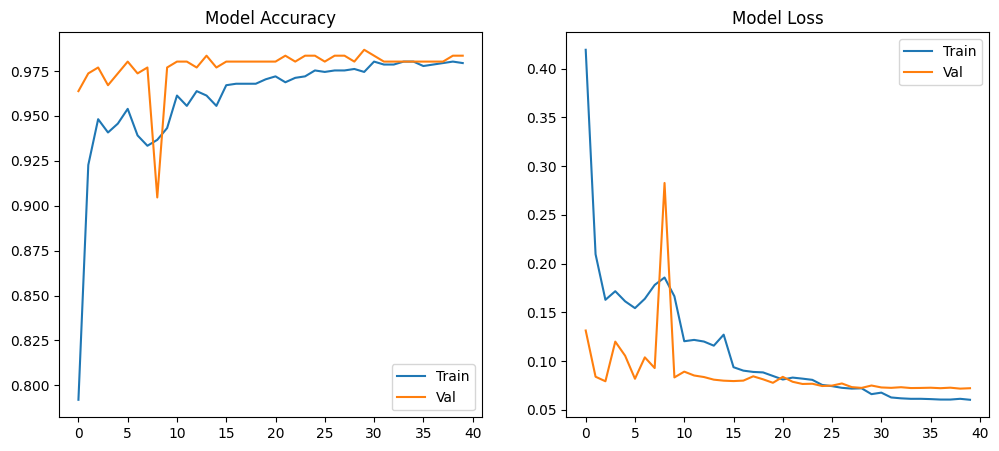

12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 974ms/step


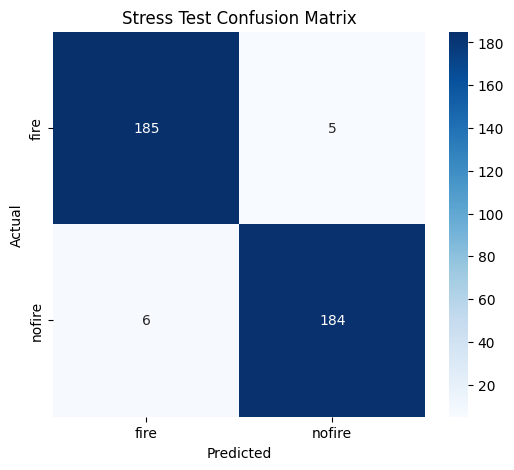

              precision    recall  f1-score   support

        fire       0.97      0.97      0.97       190
      nofire       0.97      0.97      0.97       190

    accuracy                           0.97       380
   macro avg       0.97      0.97      0.97       380
weighted avg       0.97      0.97      0.97       380



In [ ]:
import os, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# 1. UNZIP DATASET (Upload 'Forest Fire Dataset.zip' to sidebar first)
zip_name = 'Forest Fire Dataset.zip'
if os.path.exists(zip_name):
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall('forest_fire_data')
    DATA_PATH = 'forest_fire_data/Forest Fire Dataset'
    train_dir, test_dir = os.path.join(DATA_PATH, 'Training'), os.path.join(DATA_PATH, 'Testing')

# 2. DATA GENERATORS (Original Logic: No Augmentation)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32, class_mode='categorical', subset='training')
val_gen = datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32, class_mode='categorical', subset='validation')

test_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
test_df = pd.DataFrame({'filename': test_files, 'label': ['fire' if f.lower().startswith('fire') else 'nofire' for f in test_files]})
test_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(test_df, directory=test_dir, x_col='filename', y_col='label', target_size=(256, 256), batch_size=32, class_mode='categorical', shuffle=False)

# 3. ORIGINAL ARCHITECTURE (Logic Untouched)
def build_mhcnnfd_model(num_classes=2):
    inputs = tf.keras.Input(shape=(256, 256, 3))
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    x = tf.keras.layers.Conv2D(48, (3, 3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    x = tf.keras.layers.Conv2D(56, (3, 3), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(64, activation='selu')(x)
    x = tf.keras.layers.Dense(56, activation='selu')(x)
    x = tf.keras.layers.Dense(32, activation='selu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

model = build_mhcnnfd_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda e: 1e-3 if e<15 else (1e-4 if e<31 else 1e-5))

# 4. TRAIN
history = model.fit(train_gen, validation_data=val_gen, epochs=40, callbacks=[lr_callback])

# 5. VISUALIZATION - ACCURACY & LOSS CURVES
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title('Model Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title('Model Loss'); plt.legend()
plt.show()

# 6. VISUALIZATION - CONFUSION MATRIX
y_pred = np.argmax(model.predict(test_gen), axis=1)
cm = confusion_matrix(test_gen.classes, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['fire', 'nofire'], yticklabels=['fire', 'nofire'])
plt.title('Stress Test Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()
print(classification_report(test_gen.classes, y_pred, target_names=['fire', 'nofire']))